# Task 1: Exploring and Visualizing the Iris Dataset

**Objective:** Load, inspect, and visualize the Iris dataset to understand data trends and distributions.

**Dataset:** Iris Dataset (loaded via seaborn)

**Skills Practiced:**
- Data loading and inspection using pandas
- Descriptive statistics and data exploration
- Basic plotting and visualization with seaborn and matplotlib

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Set a clean plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# Load the Iris dataset from seaborn's built-in datasets
df = sns.load_dataset('iris')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}  →  {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Column names: {list(df.columns)}')

Dataset loaded successfully!
Shape: (150, 5)  →  150 rows × 5 columns
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


## Step 3: First Look at the Data

In [3]:
# Display the first 5 rows
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Info: data types and non-null counts
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [5]:
# Summary statistics for numeric columns
print('=== Summary Statistics ===')
df.describe()

=== Summary Statistics ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Check class distribution
print('=== Species Distribution ===')
print(df['species'].value_counts())

# Check for missing values
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\nNo missing values — dataset is clean!')

=== Species Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

No missing values — dataset is clean!


## Step 4: Visualizations

### 4.1 Scatter Plot — Feature Relationships

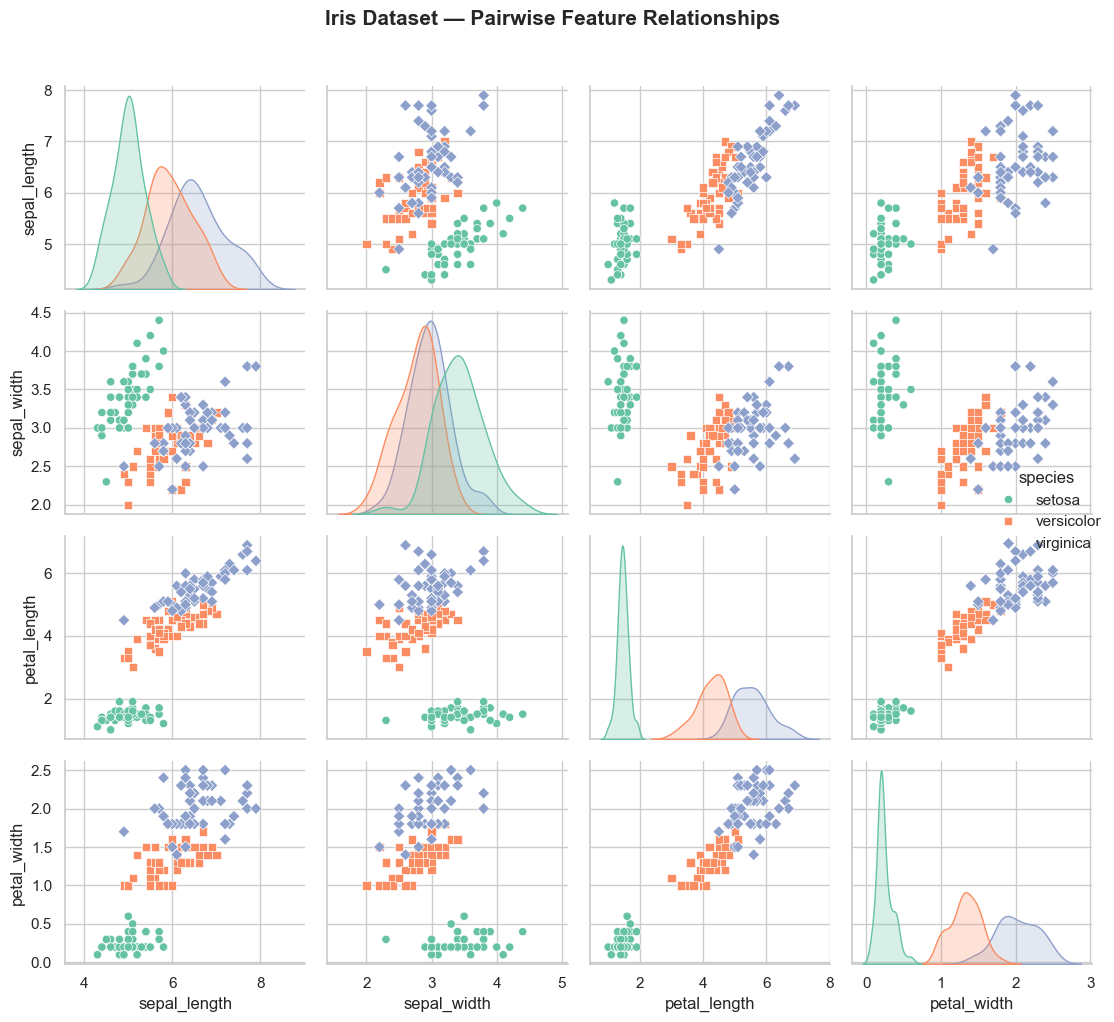


Insight: Petal length and petal width are the most discriminating features between species.


In [7]:
# Pair plot: scatter relationships between all numeric features, colored by species
fig = sns.pairplot(df, hue='species', diag_kind='kde', markers=['o', 's', 'D'])
fig.fig.suptitle('Iris Dataset — Pairwise Feature Relationships', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Petal length and petal width are the most discriminating features between species.')

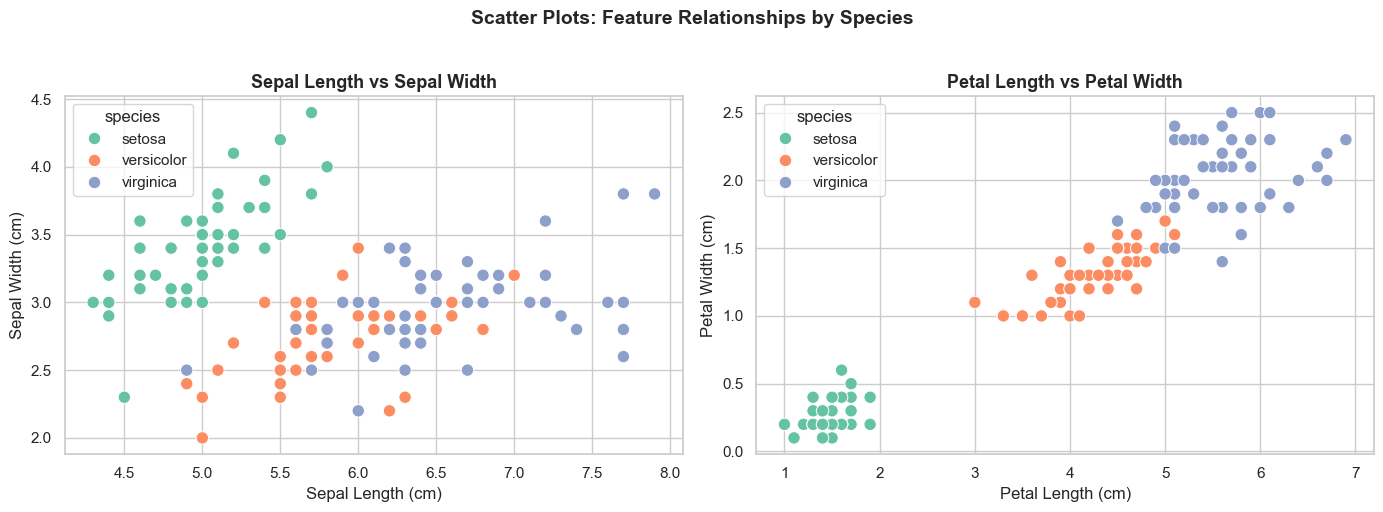

In [8]:
# Individual scatter plot: Sepal Length vs Petal Length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sepal features
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species',
                palette='Set2', s=80, ax=axes[0])
axes[0].set_title('Sepal Length vs Sepal Width', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')

# Plot 2: Petal features
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species',
                palette='Set2', s=80, ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')

plt.suptitle('Scatter Plots: Feature Relationships by Species', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Histograms — Value Distributions

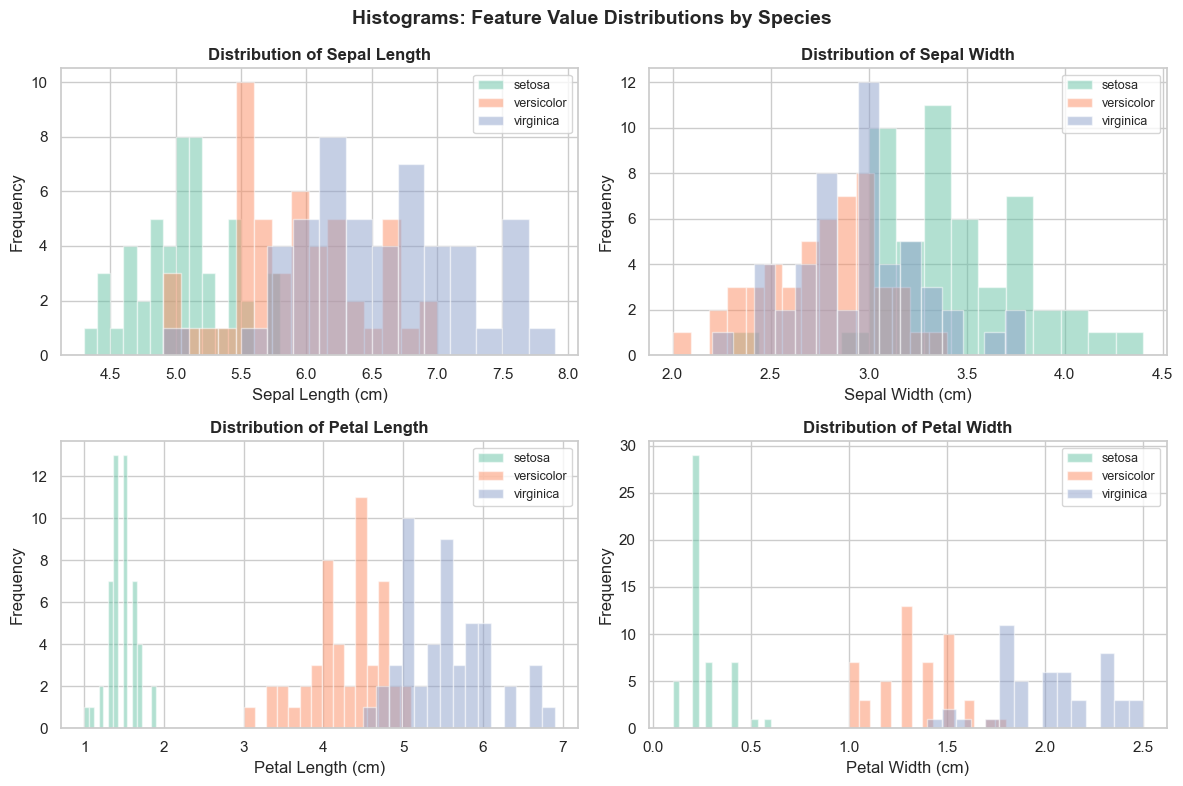


Insight: Petal features (length & width) show clear separation, making them excellent predictors.


In [9]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['steelblue', 'seagreen', 'tomato', 'orchid']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    # Plot histogram + KDE per species
    for species in df['species'].unique():
        subset = df[df['species'] == species][col]
        axes[i].hist(subset, bins=15, alpha=0.5, label=species, edgecolor='white')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{col.replace("_", " ").title()} (cm)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Histograms: Feature Value Distributions by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Petal features (length & width) show clear separation, making them excellent predictors.')

### 4.3 Box Plots — Outlier Detection

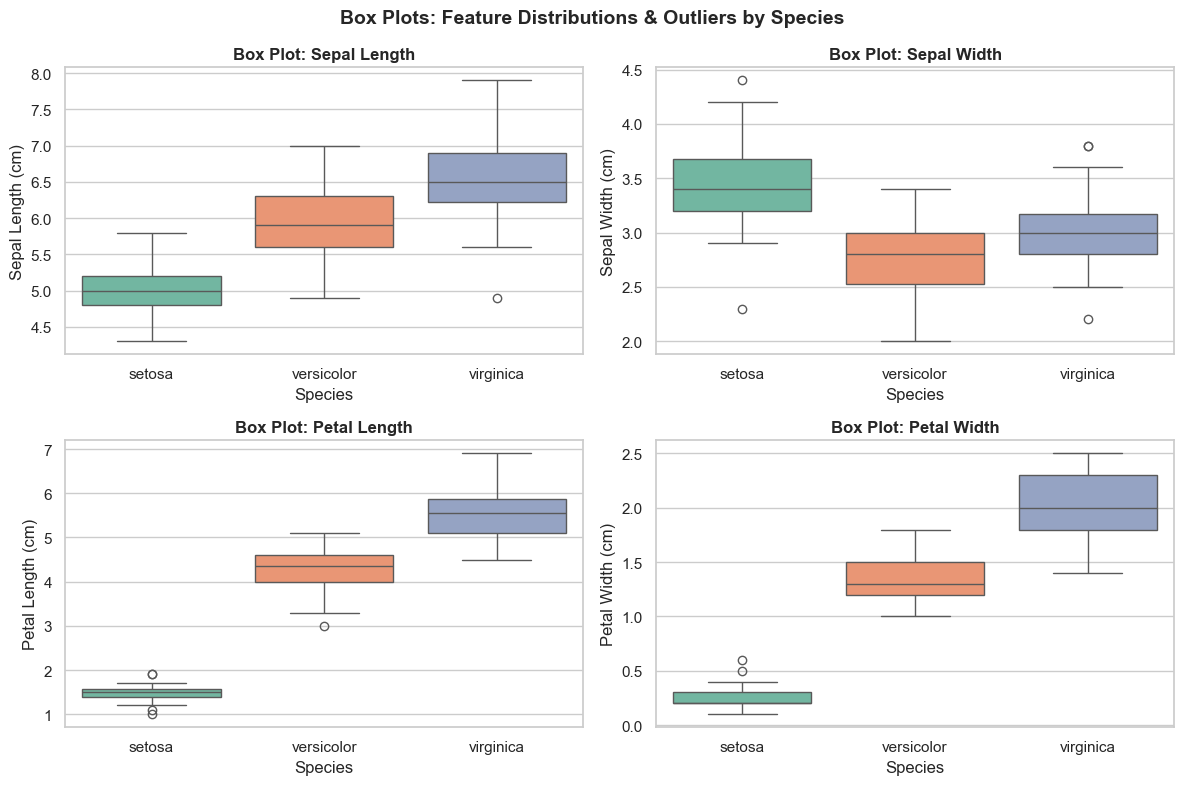


Insight: A few outliers are visible in sepal_width for setosa species.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x='species', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Box Plot: {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(f'{col.replace("_", " ").title()} (cm)')

plt.suptitle('Box Plots: Feature Distributions & Outliers by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: A few outliers are visible in sepal_width for setosa species.')

### 4.4 Correlation Heatmap

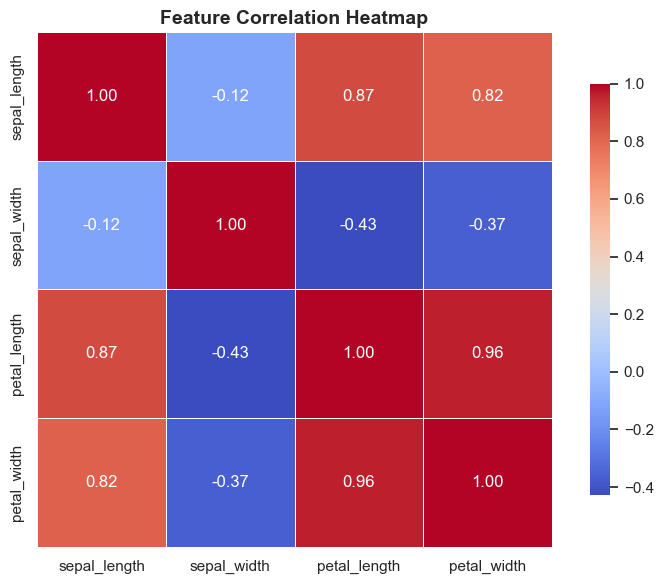


Insight: Petal length and petal width are highly correlated (r=0.96).


In [11]:
plt.figure(figsize=(8, 6))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Petal length and petal width are highly correlated (r=0.96).')

## Step 5: Summary & Key Findings

| Finding | Detail |
|---------|--------|
| Dataset size | 150 rows × 5 columns, no missing values |
| Classes | 3 species: setosa, versicolor, virginica (50 each) |
| Best discriminating features | Petal length & petal width |
| Outliers | Minor outliers in sepal_width for setosa |
| Highest correlation | petal_length ↔ petal_width (r = 0.96) |

**Conclusion:** The Iris dataset is well-balanced and clean. Petal dimensions are far more useful than sepal dimensions for distinguishing species — a finding that directly informs feature selection for any classification model built on this data.